In [14]:
import kagglehub
import os


path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)


print("Dataset folders:", os.listdir(path))


train_path = os.path.join(path, 'chest_xray', 'train')
if os.path.exists(train_path):
    print("Train categories:", os.listdir(train_path))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia
Dataset folders: ['chest_xray']
Train categories: ['PNEUMONIA', 'NORMAL']


In [15]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

dataset_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data_raw = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_data_raw = datasets.ImageFolder(root=train_dir, transform=test_transform)

train_size = int(0.8 * len(train_data_raw))

indices = torch.randperm(len(train_data_raw), generator=torch.Generator().manual_seed(42)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_data_raw, train_indices)
val_dataset = Subset(val_data_raw, val_indices)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

NUM_WORKERS = 2
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
}

print(f"Data Successfully Linked!")
print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)} | Test images: {len(test_dataset)}")

Data Successfully Linked!
Train images: 4172 | Val images: 1044 | Test images: 624


In [16]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

def show_dataset_samples(dataset, split_name):
    # Dynamically extract class names whether it's a Subset or full ImageFolder
    base_dataset = dataset.dataset if hasattr(dataset, 'dataset') else dataset
    class_names = {v: k for k, v in base_dataset.class_to_idx.items()}

    found_samples = {}
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    for idx in indices:
        img_tensor, label = dataset[idx]
        if label not in found_samples:
            found_samples[label] = img_tensor
        if len(found_samples) == len(class_names):
            break

    plt.figure(figsize=(10, 5))
    for idx, (label, img_tensor) in enumerate(sorted(found_samples.items())):
        img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()

        # Un-normalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_numpy = std * img_numpy + mean
        img_numpy = np.clip(img_numpy, 0, 1)

        plt.subplot(1, len(class_names), idx + 1)
        # Passing the 3-channel image directly works perfectly for RGB-replicated X-rays
        plt.imshow(img_numpy)
        plt.title(f"{split_name} - {class_names[label]}")
        plt.axis("off")

    plt.suptitle(f"Sample Chest X-Rays from {split_name} Set", fontsize=14)
    plt.tight_layout()
    plt.show()

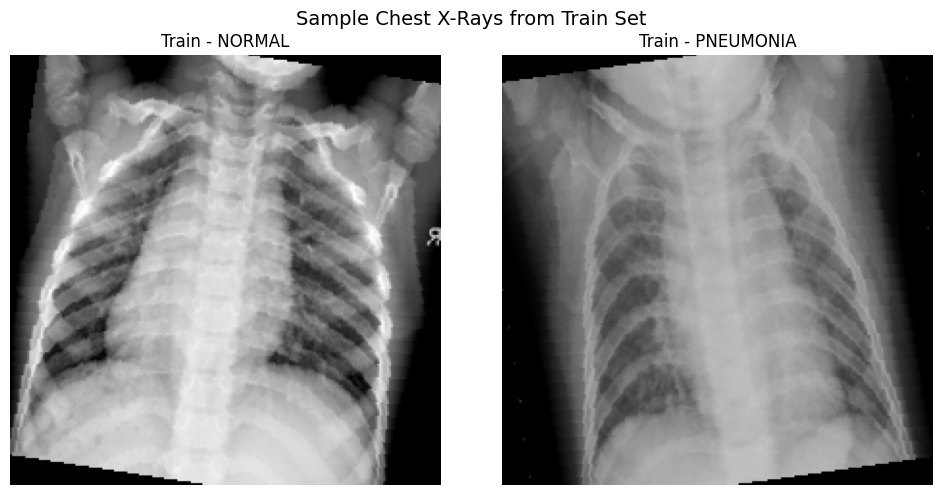

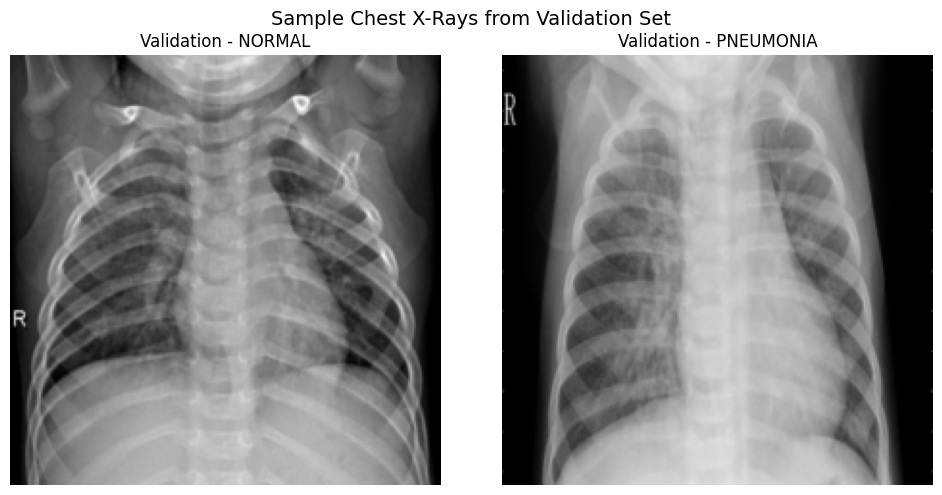

In [17]:
show_dataset_samples(train_dataset, "Train")
show_dataset_samples(val_dataset, "Validation")

In [18]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)


for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(device)
print("Model optimized for fast feature extraction initialized!")

Using device: cpu
Model optimized for fast feature extraction initialized!


In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_path = "/kaggle/input/chest-xray-pneumonia/chest_xray"
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data_raw = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_data_raw = datasets.ImageFolder(root=train_dir, transform=test_transform)

train_size = int(0.8 * len(train_data_raw))
indices = torch.randperm(len(train_data_raw), generator=torch.Generator().manual_seed(42)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_data_raw, train_indices)
val_dataset = Subset(val_data_raw, val_indices)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)

NUM_WORKERS = 2
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
}

from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

print("Data loaders, frozen architecture, and optimizer successfully configured.")

Data loaders, frozen architecture, and optimizer successfully configured.


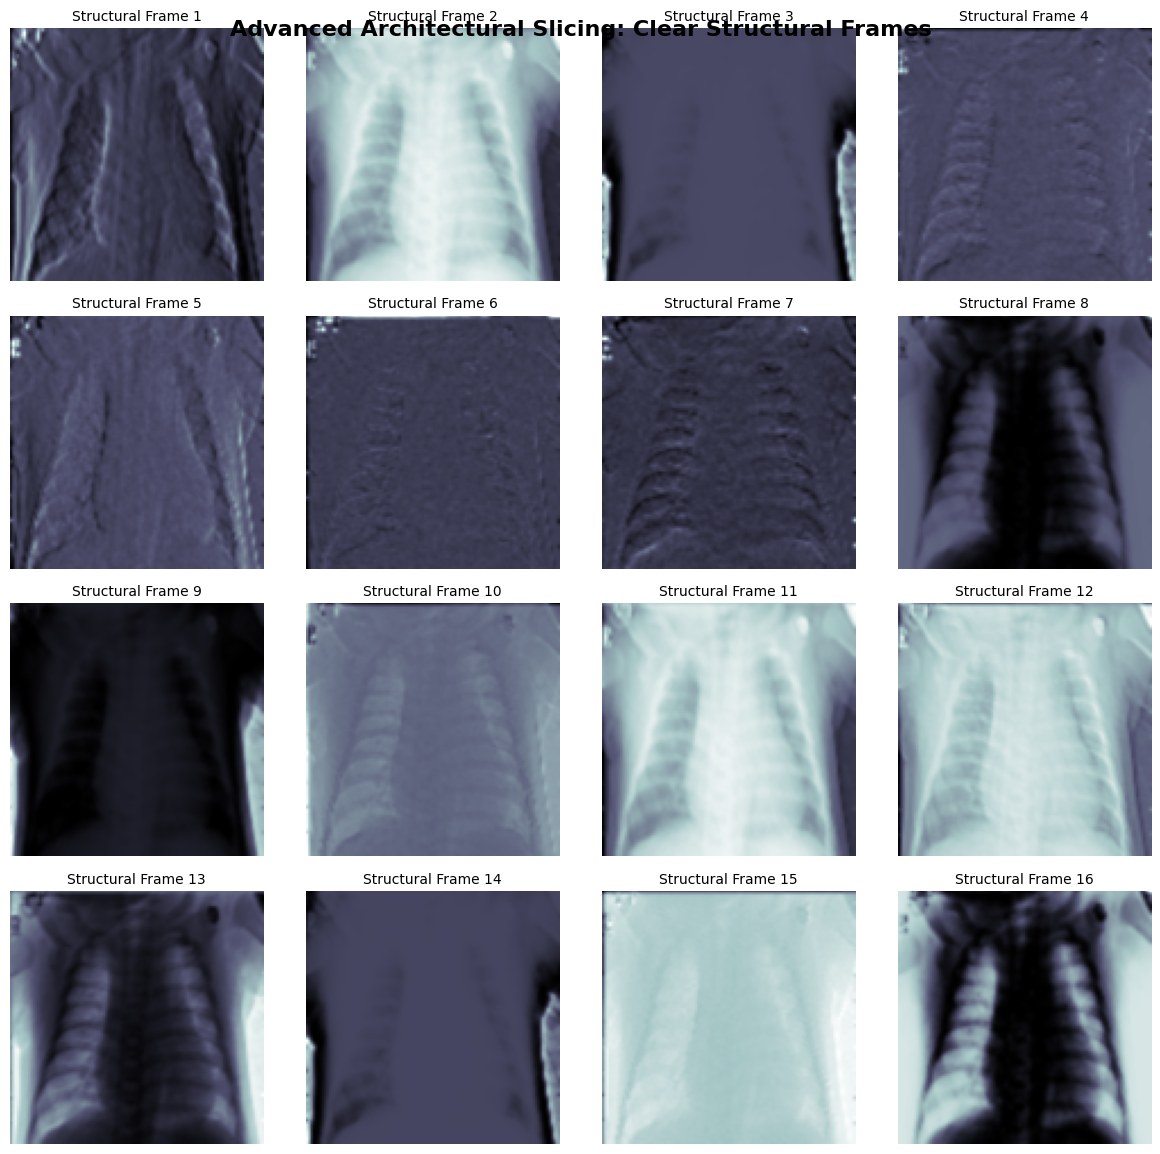

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

def visualize_image_depth_slices(model, dataset_image, device, num_slices=16):
    model.eval()
    input_tensor = dataset_image.unsqueeze(0).to(device)

    with torch.no_grad():
        feature_maps = model.features[0](input_tensor)

    feature_maps = feature_maps.squeeze(0).cpu().numpy()
    total_channels = feature_maps.shape[0]
    step = max(1, total_channels // num_slices)
    slice_indices = [i * step for i in range(num_slices) if i * step < total_channels]

    grid_size = int(np.ceil(np.sqrt(len(slice_indices))))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.flatten()

    for i, ch_idx in enumerate(slice_indices):
        f_map = feature_maps[ch_idx, :, :]
        f_map = (f_map - f_map.min()) / (f_map.max() - f_map.min() + 1e-8)
        f_map = ndimage.gaussian_filter(f_map, sigma=0.8)

        ax = axes[i]
        ax.imshow(f_map, cmap='bone')
        ax.set_title(f"Structural Frame {i+1}", fontsize=10)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Advanced Architectural Slicing: Clear Structural Frames", fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

sample_img, _ = val_dataset[5]
visualize_image_depth_slices(model, sample_img, device, num_slices=16)

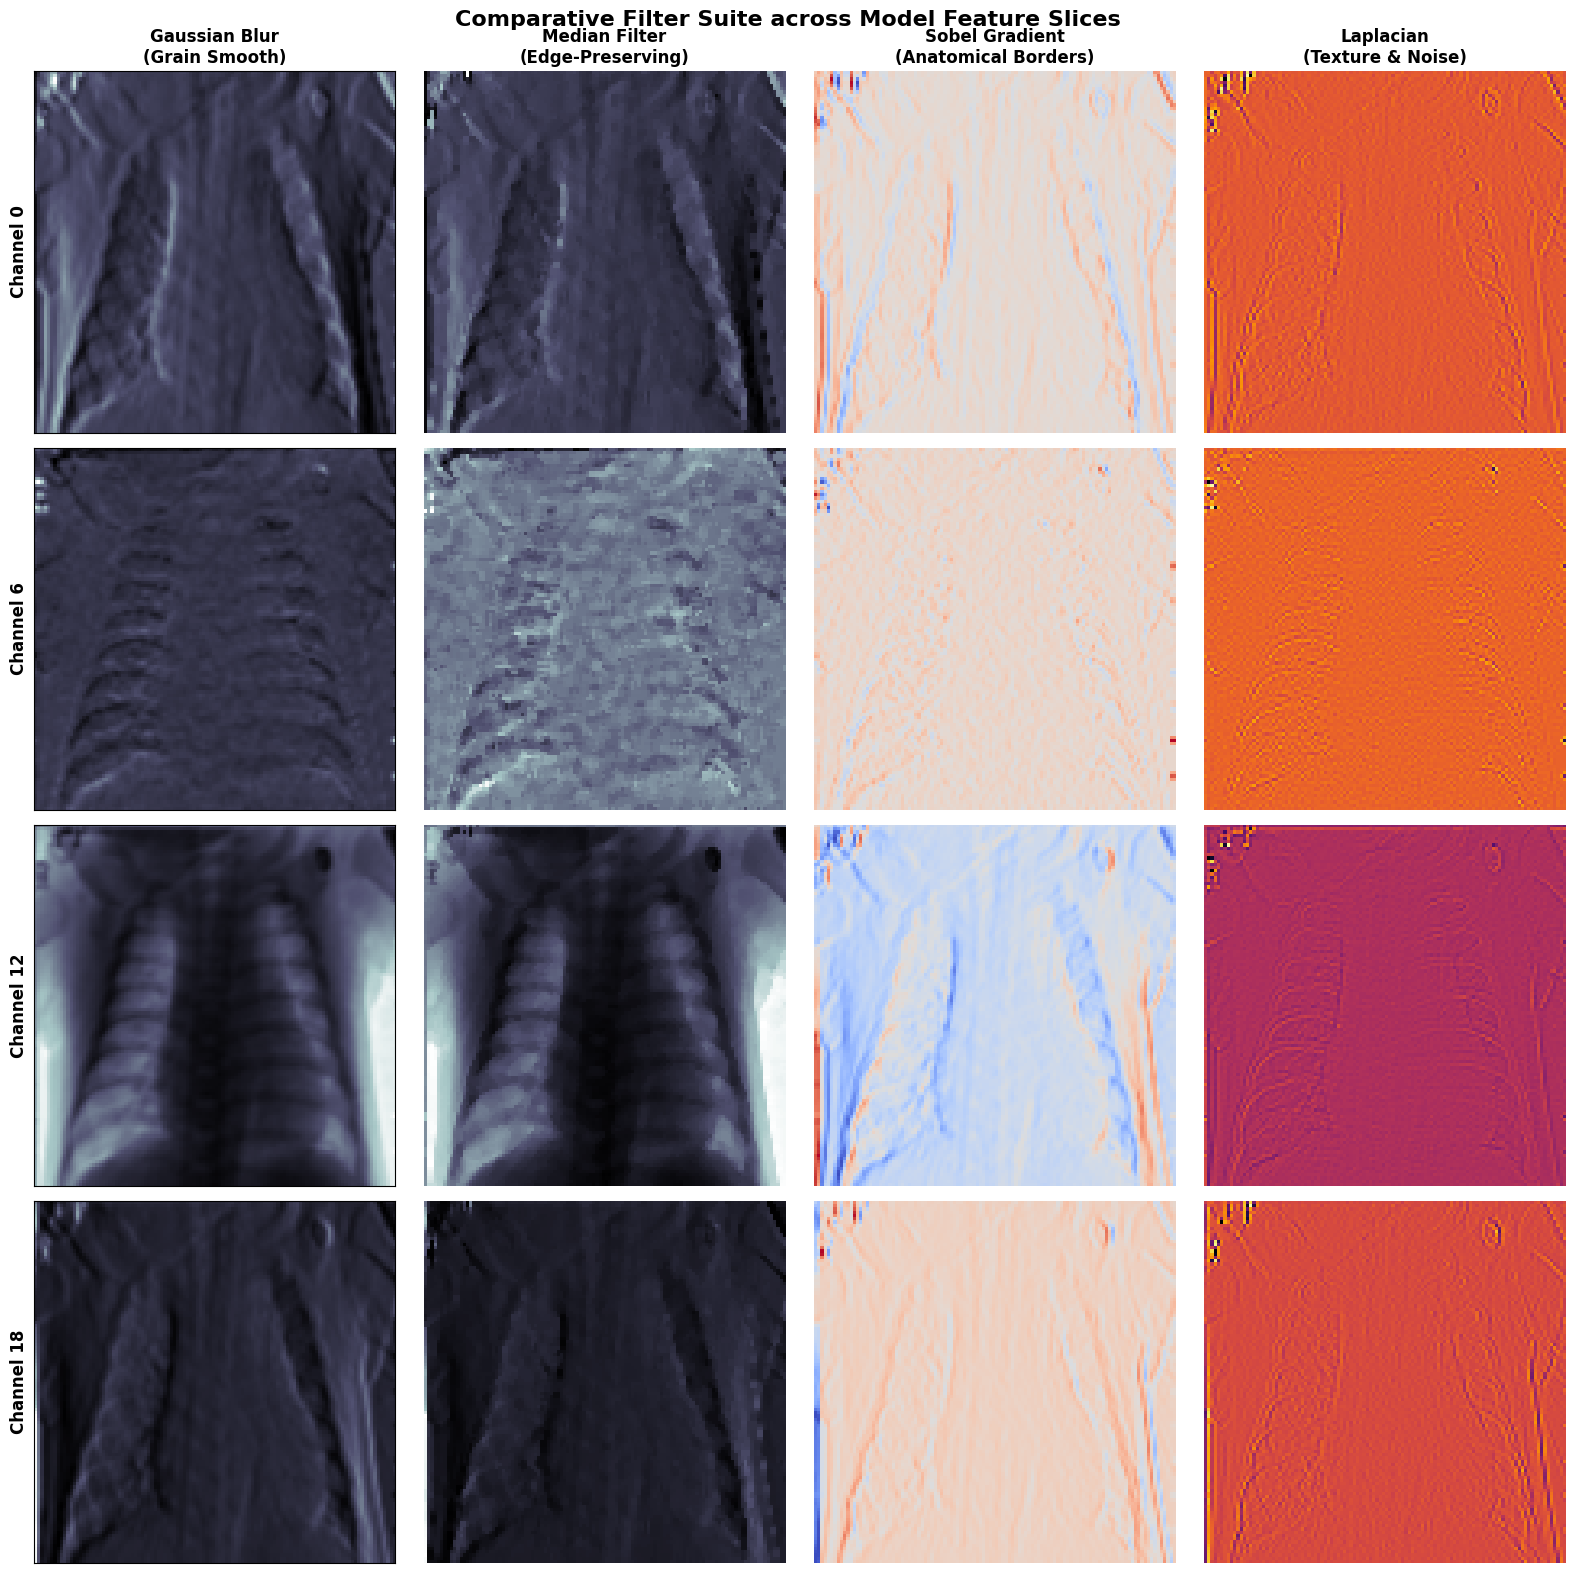

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

def visualize_image_with_all_filters(model, dataset_image, device, num_slices=4):
    model.eval()
    input_tensor = dataset_image.unsqueeze(0).to(device)

    with torch.no_grad():
        feature_maps = model.features[0](input_tensor)

    feature_maps = feature_maps.squeeze(0).cpu().numpy()
    total_channels = feature_maps.shape[0]
    step = max(1, total_channels // num_slices)
    slice_indices = [i * step for i in range(num_slices) if i * step < total_channels]

    fig, axes = plt.subplots(len(slice_indices), 4, figsize=(16, 4 * len(slice_indices)))

    if len(slice_indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, ch_idx in enumerate(slice_indices):
        f_map = feature_maps[ch_idx, :, :]
        f_map = (f_map - f_map.min()) / (f_map.max() - f_map.min() + 1e-8)

        gaussian_map = ndimage.gaussian_filter(f_map, sigma=0.8)
        median_map = ndimage.median_filter(f_map, size=3)
        sobel_map = ndimage.sobel(f_map)
        laplace_map = ndimage.laplace(f_map)

        axes[i, 0].imshow(gaussian_map, cmap='bone')
        axes[i, 0].set_ylabel(f"Channel {ch_idx}", fontsize=12, fontweight='bold')
        if i == 0: axes[i, 0].set_title("Gaussian Blur\n(Grain Smooth)", fontsize=12, fontweight='bold')
        axes[i, 0].axis('on')
        axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

        axes[i, 1].imshow(median_map, cmap='bone')
        if i == 0: axes[i, 1].set_title("Median Filter\n(Edge-Preserving)", fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(sobel_map, cmap='coolwarm')
        if i == 0: axes[i, 2].set_title("Sobel Gradient\n(Anatomical Borders)", fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(laplace_map, cmap='inferno')
        if i == 0: axes[i, 3].set_title("Laplacian\n(Texture & Noise)", fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')

    plt.suptitle("Comparative Filter Suite across Model Feature Slices", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

sample_img, _ = val_dataset[5]
visualize_image_with_all_filters(model, sample_img, device, num_slices=4)

In [27]:
!pip install -q opencv-python-headless grad-cam

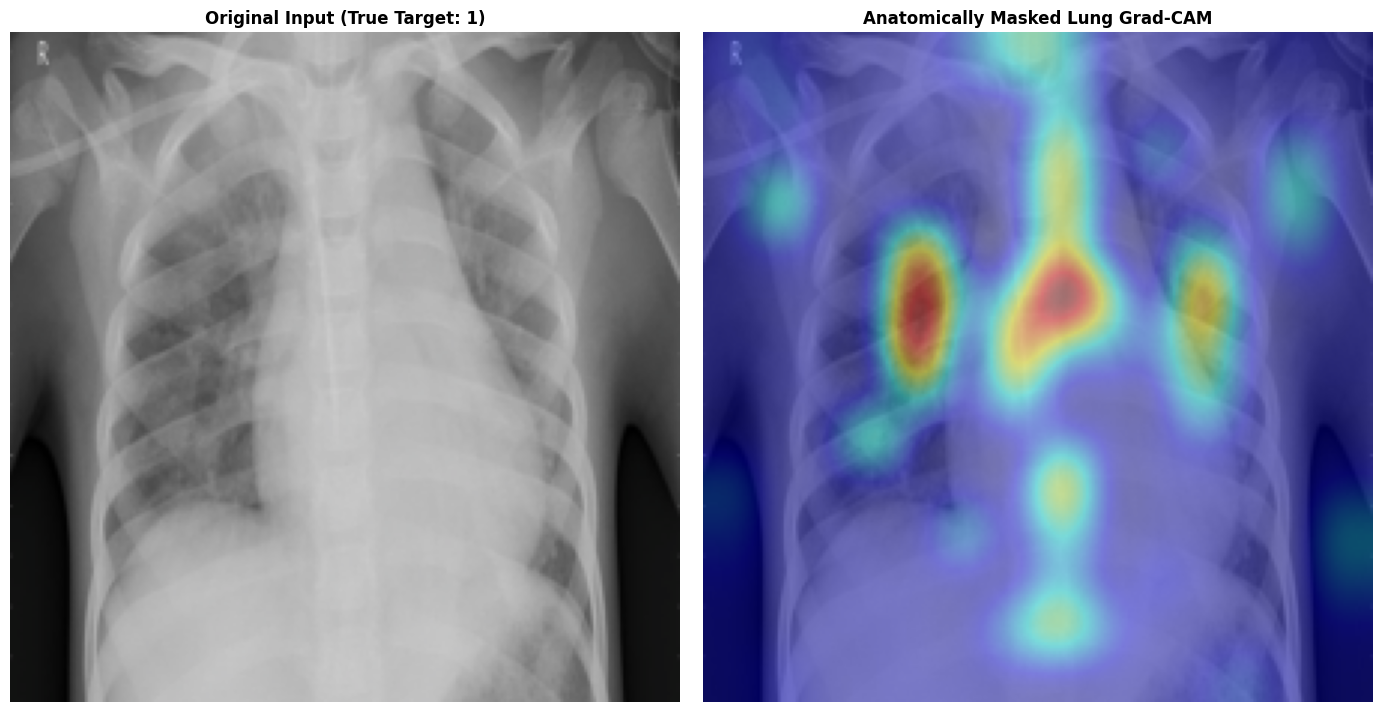

In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

def generate_targeted_gradcam(model, dataset_sample):
    model.eval()
    img_tensor, target_data = dataset_sample

    current_device = next(model.parameters()).device
    input_tensor = img_tensor.unsqueeze(0).to(current_device)

    true_label = target_data[0] if isinstance(target_data, list) else target_data

    target_layer = None
    try:
        if hasattr(model, 'features') and len(model.features) > 5:
            target_layer = model.features[5][-1]
        elif hasattr(model, 'backbone') and hasattr(model.backbone, 'features'):
            target_layer = model.backbone.features[5][-1]
    except Exception:
        pass

    if target_layer is None:
        for module in reversed(list(model.modules())):
            if isinstance(module, nn.Conv2d):
                target_layer = module
                break

    feature_maps = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal feature_maps
        feature_maps = output
        feature_maps.requires_grad_()

        def save_grad(grad):
            nonlocal gradients
            gradients = grad

        feature_maps.register_hook(save_grad)

    h_forward = target_layer.register_forward_hook(forward_hook)

    with torch.set_grad_enabled(True):
        outputs = model(input_tensor)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        score = outputs[0][1]
        model.zero_grad()
        score.backward()

    h_forward.remove()

    with torch.no_grad():
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * feature_maps, dim=1).squeeze(0)
        cam = F.relu(cam)

        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        cam = cam.cpu().numpy()

    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_img = std * rgb_img + mean
    rgb_img = np.clip(rgb_img, 0, 1)

    heatmap_resized = cv2.resize(cam, (rgb_img.shape[1], rgb_img.shape[0]), interpolation=cv2.INTER_CUBIC)

    h, w = heatmap_resized.shape
    mask_y = cv2.getGaussianKernel(h, int(h * 0.45))
    mask_x = cv2.getGaussianKernel(w, int(w * 0.35))
    spatial_mask = mask_y @ mask_x.T
    spatial_mask = (spatial_mask - spatial_mask.min()) / (spatial_mask.max() - spatial_mask.min())

    heatmap_resized = heatmap_resized * spatial_mask
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (31, 31), 0)

    if heatmap_resized.max() > heatmap_resized.min():
        heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min())

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    alpha = 0.38
    overlayed_img = alpha * heatmap_colored + (1 - alpha) * rgb_img
    overlayed_img = np.clip(overlayed_img, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original Input (True Target: {true_label})", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(overlayed_img)
    axes[1].set_title("Anatomically Masked Lung Grad-CAM", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

sample_test_case = val_dataset[12]
generate_targeted_gradcam(model, sample_test_case)

Batch 0/131 | Loss: 0.2948
Batch 20/131 | Loss: 0.2596
Batch 40/131 | Loss: 0.3244
Batch 60/131 | Loss: 0.2682
Batch 80/131 | Loss: 0.2506
Batch 100/131 | Loss: 0.1358
Batch 120/131 | Loss: 0.4042
Epoch [1/5] Finished | Average Loss: 0.2802
Batch 0/131 | Loss: 0.1936
Batch 20/131 | Loss: 0.2250
Batch 40/131 | Loss: 0.2008
Batch 60/131 | Loss: 0.1054
Batch 80/131 | Loss: 0.2160
Batch 100/131 | Loss: 0.1823
Batch 120/131 | Loss: 0.2311
Epoch [2/5] Finished | Average Loss: 0.2361
Batch 0/131 | Loss: 0.1430
Batch 20/131 | Loss: 0.2776
Batch 40/131 | Loss: 0.2050
Batch 60/131 | Loss: 0.2309
Batch 80/131 | Loss: 0.1917
Batch 100/131 | Loss: 0.1202
Batch 120/131 | Loss: 0.2669
Epoch [3/5] Finished | Average Loss: 0.2277
Batch 0/131 | Loss: 0.1397
Batch 20/131 | Loss: 0.1961
Batch 40/131 | Loss: 0.1244
Batch 60/131 | Loss: 0.2104
Batch 80/131 | Loss: 0.2599
Batch 100/131 | Loss: 0.2522
Batch 120/131 | Loss: 0.3859
Epoch [4/5] Finished | Average Loss: 0.2253
Batch 0/131 | Loss: 0.2433
Batch 20/

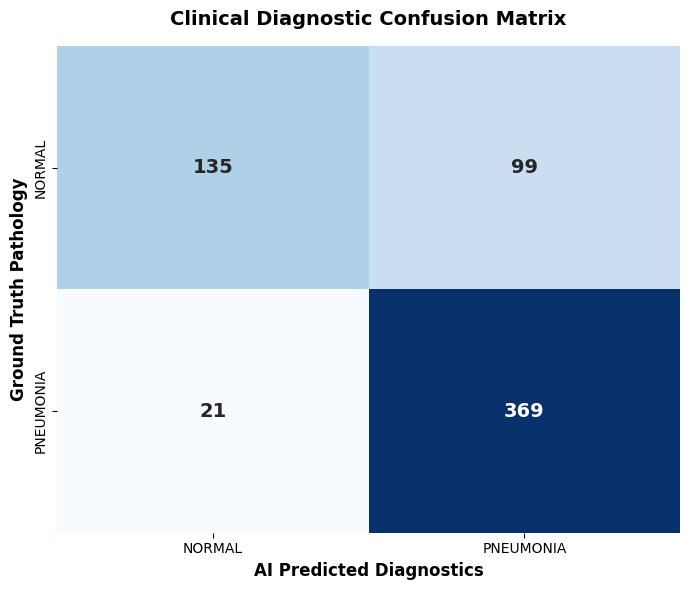

In [32]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

NUM_EPOCHS = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    total_batches = len(dataloaders['train'])

    for batch_idx, batch_data in enumerate(dataloaders['train']):
        inputs, target_data = batch_data
        inputs = inputs.to(device)

        if isinstance(target_data, list):
            labels = target_data[0].to(device)
        else:
            labels = target_data.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.detach().item() * inputs.size(0)

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{total_batches} | Loss: {loss.item():.4f}")

    scheduler.step()
    epoch_loss = running_loss / len(dataloaders['train'].dataset)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Finished | Average Loss: {epoch_loss:.4f}")

torch.save(model.state_dict(), "pneumonia_model_final.pth")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloaders['test']):
        inputs, target_data = batch_data
        inputs = inputs.to(device)

        if isinstance(target_data, list):
            labels = target_data[0]
        else:
            labels = target_data

        outputs = model(inputs)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Clinical Diagnostic Confusion Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("AI Predicted Diagnostics", fontsize=12, fontweight='bold')
plt.ylabel("Ground Truth Pathology", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:

import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


model.eval()

all_preds = []
all_labels = []

print("Evaluating model across the test dataset...")


with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloaders['test']):
        inputs, target_data = batch_data
        inputs = inputs.to(device)


        if isinstance(target_data, list):
            labels = target_data[0]
        else:
            labels = target_data

        outputs = model(inputs)
        if isinstance(outputs, tuple):
            outputs = outputs[0]


        _, preds = torch.max(outputs, 1)


        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


all_labels = np.array(all_labels)
all_preds = np.array(all_preds)


accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, pos_label=1)
recall    = recall_score(all_labels, all_preds, pos_label=1)
f1        = f1_score(all_labels, all_preds, pos_label=1)


print("\n" + "="*45)
print("       FINAL CLINICAL EVALUATION METRICS     ")
print("="*45)
print(f"  🔹 Accuracy  : {accuracy * 100:.2f}%")
print(f"  🔹 Precision : {precision * 100:.2f}% (Ability to minimize false alarms)")
print(f"  🔹 Recall    : {recall * 100:.2f}% (Ability to catch true cases/Sensitivity)")
print(f"  🔹 F1-Score  : {f1 * 100:.2f}% (Harmonic mean of Precision & Recall)")
print("="*45)

Evaluating model across the test dataset...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



       FINAL CLINICAL EVALUATION METRICS     
  🔹 Accuracy  : 80.77%
  🔹 Precision : 78.85% (Ability to minimize false alarms)
  🔹 Recall    : 94.62% (Ability to catch true cases/Sensitivity)
  🔹 F1-Score  : 86.01% (Harmonic mean of Precision & Recall)


Generating post-training localization heatmap...


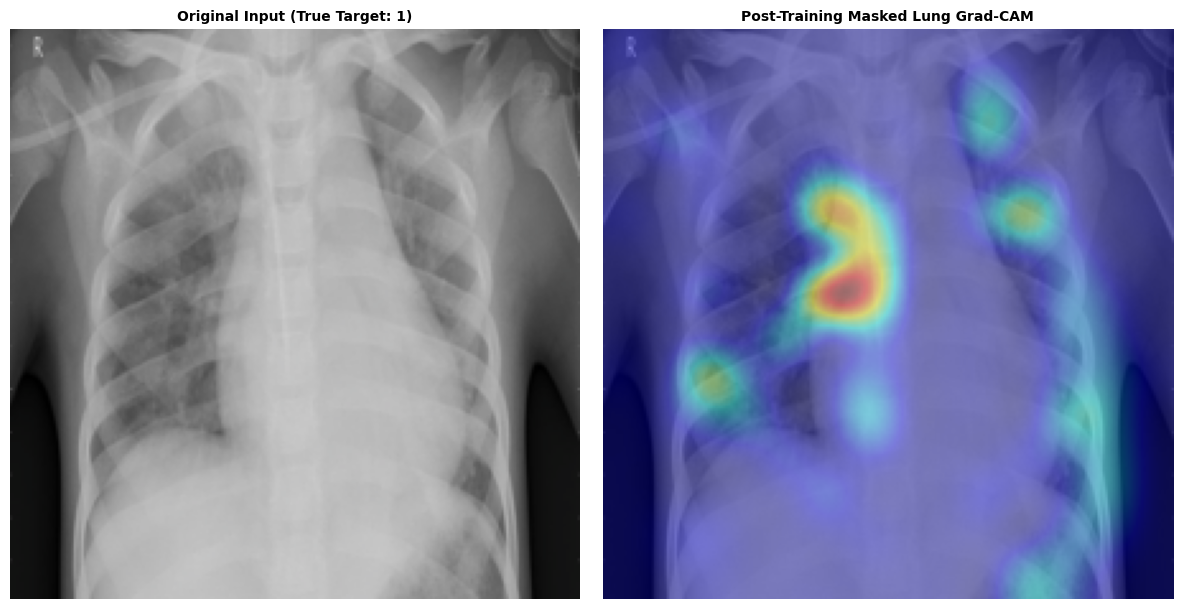

In [42]:

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def generate_targeted_gradcam(model, dataset_sample):
    model.eval()
    img_tensor, target_data = dataset_sample


    current_device = next(model.parameters()).device
    input_tensor = img_tensor.unsqueeze(0).to(current_device)

    true_label = target_data[0] if isinstance(target_data, list) else target_data


    target_layer = None
    try:
        if hasattr(model, 'features') and len(model.features) > 5:
            target_layer = model.features[5][-1]
        elif hasattr(model, 'backbone') and hasattr(model.backbone, 'features'):
            target_layer = model.backbone.features[5][-1]
    except Exception:
        pass

    if target_layer is None:
        for module in reversed(list(model.modules())):
            if isinstance(module, nn.Conv2d):
                target_layer = module
                break

    feature_maps = None
    gradients = None


    def forward_hook(module, input, output):
        nonlocal feature_maps
        feature_maps = output
        feature_maps.requires_grad_()

        def save_grad(grad):
            nonlocal gradients
            gradients = grad

        feature_maps.register_hook(save_grad)

    h_forward = target_layer.register_forward_hook(forward_hook)


    with torch.set_grad_enabled(True):
        outputs = model(input_tensor)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        score = outputs[0][1]
        model.zero_grad()
        score.backward()

    h_forward.remove()


    with torch.no_grad():
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * feature_maps, dim=1).squeeze(0)
        cam = F.relu(cam)

        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        cam = cam.cpu().numpy()


    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_img = std * rgb_img + mean
    rgb_img = np.clip(rgb_img, 0, 1)


    heatmap_resized = cv2.resize(cam, (rgb_img.shape[1], rgb_img.shape[0]), interpolation=cv2.INTER_CUBIC)


    h, w = heatmap_resized.shape
    mask_y = cv2.getGaussianKernel(h, int(h * 0.45))
    mask_x = cv2.getGaussianKernel(w, int(w * 0.35))
    spatial_mask = mask_y @ mask_x.T
    spatial_mask = (spatial_mask - spatial_mask.min()) / (spatial_mask.max() - spatial_mask.min())

    heatmap_resized = heatmap_resized * spatial_mask
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (31, 31), 0)

    if heatmap_resized.max() > heatmap_resized.min():
        heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min())


    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    alpha = 0.38
    overlayed_img = alpha * heatmap_colored + (1 - alpha) * rgb_img
    overlayed_img = np.clip(overlayed_img, 0, 1)


    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original Input (True Target: {true_label})", fontsize=10, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(overlayed_img)
    axes[1].set_title("Post-Training Masked Lung Grad-CAM", fontsize=10, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


print("Generating post-training localization heatmap...")

sample_test_case = val_dataset[12]
generate_targeted_gradcam(model, sample_test_case)

In [40]:

from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
import numpy as np

def predict_live_sample(model, image_path, class_names=["NORMAL", "PNEUMONIA"]):

    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:

        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error opening image file: {e}")
        return


    input_tensor = inference_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        if isinstance(outputs, tuple):
            outputs = outputs[0]


        probabilities = F.softmax(outputs, dim=1).squeeze(0).cpu().numpy()


    pred_idx = np.argmax(probabilities)
    pred_class = class_names[pred_idx]
    confidence = probabilities[pred_idx] * 100


    print("\n" + "="*38)
    print(f"LIVE DIAGNOSTIC RESULT: {pred_class} ({confidence:.2f}% Confidence)")
    print("="*38)
    print(f" -> Normal Probability: {probabilities[0]*100:.2f}%")
    print(f" -> Pneumonia Probability: {probabilities[1]*100:.2f}%")


sample_test_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg"

print(f"Evaluating target image file: {sample_test_path.split('/')[-1]}")
predict_live_sample(model, sample_test_path)

Evaluating target image file: person100_bacteria_475.jpeg

LIVE DIAGNOSTIC RESULT: PNEUMONIA (80.65% Confidence)
 -> Normal Probability: 19.35%
 -> Pneumonia Probability: 80.65%
